# Heart Disease Machine Learning Pipeline

This notebook builds a machine learning pipeline for predicting the presence of heart disease using the UCI Heart Disease dataset.

## Objectives

- Load the prepared healthcare dataset
- Separate features and target
- Split the data into training and testing sets
- Handle missing values without data leakage
- Preprocess numerical and categorical features
- Train multiple machine learning models
- Evaluate and compare model performance

In [1]:
import pandas as pd
import numpy as np

print("Core libraries imported successfully!")

Core libraries imported successfully!


In [2]:
df = pd.read_csv("../data/heart_disease_eda.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (303, 14)


In [3]:
X = df.drop(columns=["heart_disease"])
y = df["heart_disease"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (303, 13)
Target shape: (303,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training features: (242, 13)
Testing features: (61, 13)
Training targets: (242,)
Testing targets: (61,)


In [5]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training class distribution:
heart_disease
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Testing class distribution:
heart_disease
0    0.540984
1    0.459016
Name: proportion, dtype: float64


In [6]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

print("\nTotal features:",
      len(numerical_features) + len(categorical_features))

Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

Total features: 13


In [7]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("Numerical and categorical pipelines created successfully!")

Numerical and categorical pipelines created successfully!


In [8]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [9]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

print("Logistic Regression pipeline created successfully!")

Logistic Regression pipeline created successfully!


In [10]:
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [11]:
y_pred_logistic = logistic_pipeline.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_logistic))
print("First 10 predictions:", y_pred_logistic[:10])

Predictions generated successfully!
Number of predictions: 61
First 10 predictions: [0 1 0 0 0 0 0 0 1 0]


In [12]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)
print(f"Accuracy Percentage: {logistic_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 0.8688524590163934
Accuracy Percentage: 86.89%


In [13]:
from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[27  6]
 [ 2 26]]


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.8125
Recall: 0.9286
F1 Score: 0.8667


In [15]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [16]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [17]:
y_pred_rf = random_forest_pipeline.predict(X_test)

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(y_pred_rf))
print("First 10 predictions:", y_pred_rf[:10])

Random Forest predictions generated successfully!
Number of predictions: 61
First 10 predictions: [0 1 0 0 0 0 0 0 1 0]


In [18]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print(f"Accuracy Percentage: {rf_accuracy * 100:.2f}%")

Random Forest Accuracy: 0.8852459016393442
Accuracy Percentage: 88.52%


In [19]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[28  5]
 [ 2 26]]


In [20]:
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest Recall: {rf_recall:.4f}")
print(f"Random Forest F1 Score: {rf_f1:.4f}")

Random Forest Precision: 0.8387
Random Forest Recall: 0.9286
Random Forest F1 Score: 0.8814


In [21]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [22]:
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("First 5 Logistic Regression probabilities:")
print(y_prob_logistic[:5])

print("\nFirst 5 Random Forest probabilities:")
print(y_prob_rf[:5])

First 5 Logistic Regression probabilities:
[0.21724573 0.58128632 0.02410892 0.0369686  0.3337398 ]

First 5 Random Forest probabilities:
[0.285 0.665 0.025 0.125 0.37 ]


In [23]:
from sklearn.metrics import roc_auc_score

logistic_roc_auc = roc_auc_score(y_test, y_prob_logistic)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Logistic Regression ROC-AUC: {logistic_roc_auc:.4f}")
print(f"Random Forest ROC-AUC: {rf_roc_auc:.4f}")

Logistic Regression ROC-AUC: 0.9578
Random Forest ROC-AUC: 0.9389


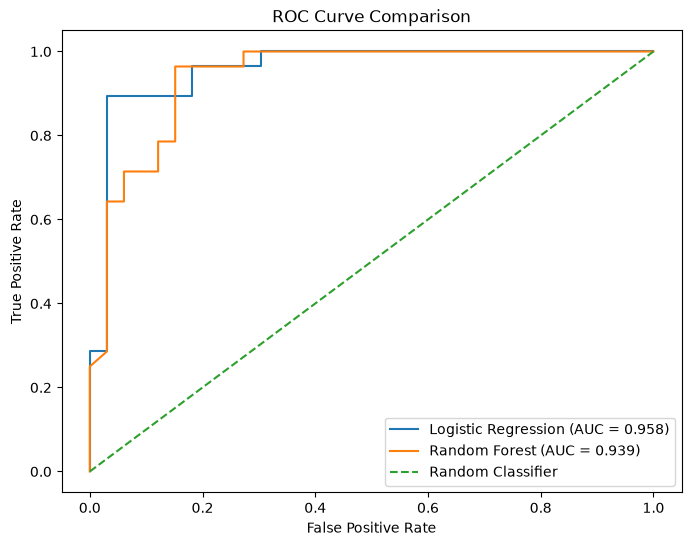

In [24]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    ))
])

gradient_boosting_pipeline.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [26]:
y_pred_gb = gradient_boosting_pipeline.predict(X_test)

print("Gradient Boosting predictions generated successfully!")
print("Number of predictions:", len(y_pred_gb))
print("First 10 predictions:", y_pred_gb[:10])

Gradient Boosting predictions generated successfully!
Number of predictions: 61
First 10 predictions: [0 1 0 0 0 0 0 0 1 0]


In [27]:
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)

print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")
print(f"Gradient Boosting Precision: {gb_precision:.4f}")
print(f"Gradient Boosting Recall: {gb_recall:.4f}")
print(f"Gradient Boosting F1 Score: {gb_f1:.4f}")

Gradient Boosting Accuracy: 0.8852
Gradient Boosting Precision: 0.8387
Gradient Boosting Recall: 0.9286
Gradient Boosting F1 Score: 0.8814


In [28]:
y_prob_gb = gradient_boosting_pipeline.predict_proba(X_test)[:, 1]

gb_roc_auc = roc_auc_score(y_test, y_prob_gb)

print(f"Gradient Boosting ROC-AUC: {gb_roc_auc:.4f}")

Gradient Boosting ROC-AUC: 0.9448


In [29]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        gb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        gb_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc,
        gb_roc_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9578
1,Random Forest,0.8852,0.8387,0.9286,0.8814,0.9389
2,Gradient Boosting,0.8852,0.8387,0.9286,0.8814,0.9448


In [30]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold stratified cross-validation configured successfully!")

5-fold stratified cross-validation configured successfully!


In [31]:
from sklearn.model_selection import cross_val_score

logistic_cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression ROC-AUC scores:")
print(logistic_cv_scores)

print(f"\nMean ROC-AUC: {logistic_cv_scores.mean():.4f}")
print(f"Standard Deviation: {logistic_cv_scores.std():.4f}")

Logistic Regression ROC-AUC scores:
[0.9180602  0.93434343 0.88986014 0.91083916 0.87937063]

Mean ROC-AUC: 0.9065
Standard Deviation: 0.0197


In [32]:
rf_cv_scores = cross_val_score(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Random Forest ROC-AUC scores:")
print(rf_cv_scores)

print(f"\nMean ROC-AUC: {rf_cv_scores.mean():.4f}")
print(f"Standard Deviation: {rf_cv_scores.std():.4f}")

Random Forest ROC-AUC scores:
[0.95317726 0.83838384 0.87237762 0.8986014  0.85926573]

Mean ROC-AUC: 0.8844
Standard Deviation: 0.0396


In [33]:
gb_cv_scores = cross_val_score(
    gradient_boosting_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Gradient Boosting ROC-AUC scores:")
print(gb_cv_scores)

print(f"\nMean ROC-AUC: {gb_cv_scores.mean():.4f}")
print(f"Standard Deviation: {gb_cv_scores.std():.4f}")

Gradient Boosting ROC-AUC scores:
[0.88628763 0.81818182 0.88811189 0.88111888 0.88986014]

Mean ROC-AUC: 0.8727
Standard Deviation: 0.0274


In [34]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean CV ROC-AUC": [
        logistic_cv_scores.mean(),
        rf_cv_scores.mean(),
        gb_cv_scores.mean()
    ],
    "CV Standard Deviation": [
        logistic_cv_scores.std(),
        rf_cv_scores.std(),
        gb_cv_scores.std()
    ]
})

cv_comparison.round(4)

,Model,Mean CV ROC-AUC,CV Standard Deviation
0,Logistic Regression,0.9065,0.0197
1,Random Forest,0.8844,0.0396
2,Gradient Boosting,0.8727,0.0274


## Phase 3 Summary

Three classification models were developed using a leakage-safe preprocessing pipeline:

- Logistic Regression
- Random Forest
- Gradient Boosting

The preprocessing pipeline handles missing values, scales numerical features, and one-hot encodes categorical features.

### Test Set Results

- Logistic Regression: 86.89% accuracy, 0.8667 F1, 0.9578 ROC-AUC
- Random Forest: 88.52% accuracy, 0.8814 F1, 0.9389 ROC-AUC
- Gradient Boosting: 88.52% accuracy, 0.8814 F1, 0.9448 ROC-AUC

### Cross-Validation Results

- Logistic Regression: 0.9065 mean ROC-AUC
- Random Forest: 0.8844 mean ROC-AUC
- Gradient Boosting: 0.8727 mean ROC-AUC

Logistic Regression showed the strongest average ROC-AUC and the lowest variation across cross-validation folds. Random Forest and Gradient Boosting achieved slightly higher accuracy and F1 score on the held-out test set.

Based on these results, Logistic Regression is the leading candidate for further evaluation. Final model selection will be performed after additional evaluation rather than relying on a single train-test split.